In [ ]:
!apt-get install libproj-dev- proj-data proj-bin
!apt-get install libgeos-dev
!pip install cartopy[plotting]
!pip install owslib
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package 'libproj-dev' is not installed, so not removed
proj-bin is already the newest version (9.1.1-1~jammy0).
proj-data is already the newest version (9.1.1-1~jammy0).
The following packages were automatically installed and are no longer required:
  default-libmysqlclient-dev libaom-dev libarmadillo-dev libarpack2-dev libblosc-dev libcfitsio-dev
  libdav1d-dev libde265-dev libfreexl-dev libfyba-dev libgif-dev libhdf4-alt-dev libheif-dev
  libjson-c-dev libkml-dev libkmlconvenience1 libkmlregionator1 libkmlxsd1 liblz4-dev
  libminizip-dev libmysqlclient-dev libnetcdf-dev libodbccr2 libogdi-dev libopenjp2-7-dev
  libpoppler-dev libpoppler-private-dev libpq-dev libqhull-dev libqhull8.0 libqhullcpp8.0
  librttopo-dev libsqlite3-dev libsuperlu-dev liburiparser-dev libwebp-dev libx265-dev
  libxerces-c-dev libzstd-dev unixodbc-dev
Use 'apt autoremove' to remove them.
0 upgraded, 0 newly install

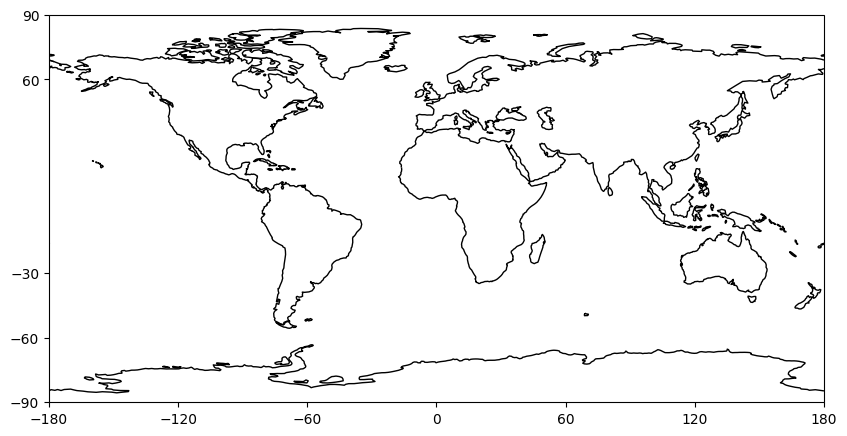

In [ ]:
proj0 = ccrs.PlateCarree(central_longitude = 0)
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection=proj0)
ax.coastlines()
ax.set_xticks([-180,-120,-60,0,60,120,180],crs=proj0)
ax.set_yticks([-90,-60,-30,60,90],crs=proj0)

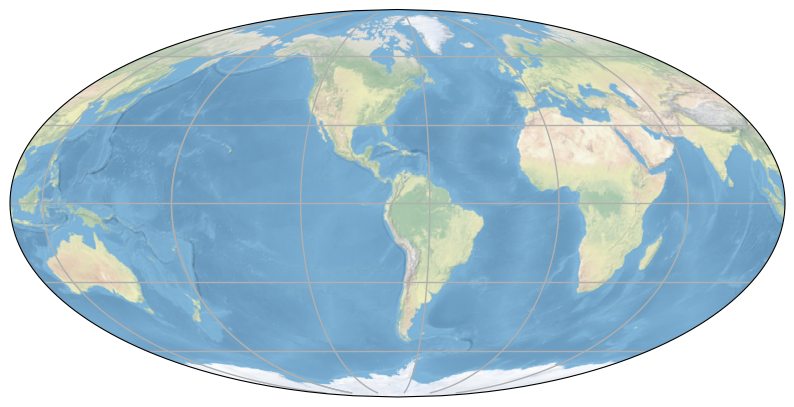

In [ ]:
proj = ccrs.Mollweide(central_longitude= -75.0) #elipse
#proj = ccrs.Orthographic(central_longitude= -90.0) #esfera
fig = plt.figure(figsize =(10,8))
ax = fig.add_subplot(111,projection = proj)
ax.stock_img()
ax.gridlines(linewidth = 1.0)

/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


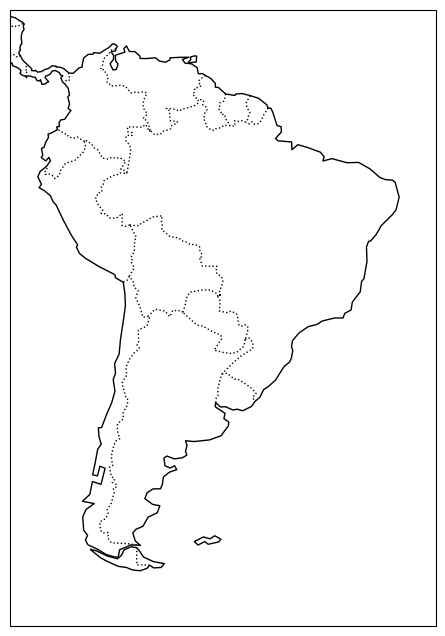

In [ ]:
import cartopy.feature as cfeature
reg = [-85,-30,-60,15]
eur = [-12,70,34,72]
proj = ccrs.PlateCarree()
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(111,projection = proj)
ax.set_extent(reg)
ax.coastlines()
ax.add_feature(cfeature.BORDERS,linestyle =':')

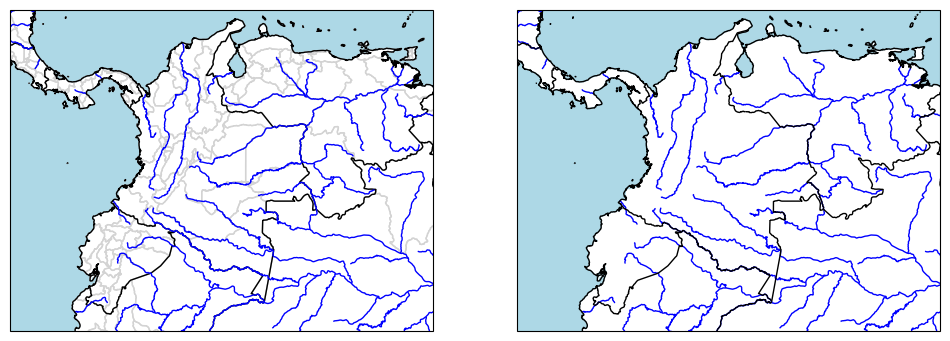

In [ ]:
countries = cfeature.NaturalEarthFeature(category = 'cultural',name = 'admin_0_boundary_lines_land',scale='10m',facecolor = 'none')
states = cfeature.NaturalEarthFeature(category='cultural',name = 'admin_1_states_provinces',scale='10m',facecolor = 'none')
rivers = cfeature.NaturalEarthFeature('physical','rivers_lake_centerlines','10m')
proj4 = ccrs.Mercator()
fig = plt.figure(figsize = (12,10))
ax = fig.add_subplot(1,2,1,projection =proj4)
ax.set_extent([-85,-60,-6,13])
ax.add_feature(cfeature.OCEAN,color = 'lightblue')
ax.add_feature(states,edgecolor = 'lightgrey')
ax.add_feature(countries,edgecolor = 'k')
ax.add_feature(rivers,edgecolor = 'blue',facecolor = 'none')
ax.coastlines(resolution ='10m')
ax2 =fig.add_subplot(1,2,2,projection = proj4)
ax2.add_feature(cfeature.OCEAN,color ='lightblue')
ax2.set_extent([-85,-60,-6,13])
ax2.add_feature(rivers,edgecolor = 'blue',facecolor = 'none')
ax2.add_feature(countries,edgecolor = 'k')
ax2.coastlines(resolution = '10m')

In [ ]:
from owslib.wms import WebMapService
frame = 'rsnc.dat'
data = pd.read_csv(frame, delim_whitespace=True, header = None)
sta = data.iloc[:,0].to_numpy()
lat = data.iloc[:,1].to_numpy()
lon = data.iloc[:,2].to_numpy()
wms_server = "https://ows.terrestris.de/osm/service?"
proj5 = ccrs.Mercator()
fig = plt.figure(figsize=(12,10),dpi = 800)
ax = fig.add_subplot(121,projection = proj5)
ax.set_extent([-85,-65, -5,15])
ax.add_wms(wms_server, layers=["SRTM30-Colored-Hillshade"])
ax.plot(lon,lat,'k^',label='Estaciones',transform =ccrs.Geodetic())
ax.legend()
ax2 = fig.add_subplot(122,projection=proj5)
ax2.set_extent([-76,-70,9,12])
ax2.add_wms(wms_server,layers=["SRTM30-Colored-Hillshade"])
ax2.plot(lon,lat,'k^',transform=ccrs.Geodetic())
